In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# LiDAR Years: data understanding

Exploration of the corrected `LiDAR_Years.gpkg` attribute export. Results in this notebook must be calculated from the new data and should not be copied from the archived 29 June notebook.

In [2]:
# Find the repository root whether Jupyter starts there or in notebooks/.
current_directory = Path.cwd().resolve()
project_root = next(
    folder
    for folder in [current_directory, *current_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

data_path = project_root / "data" / "interim" / "LiDAR_Years_attributes.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Attribute CSV not found. Run: "
        ".venv/bin/python data_preprocessing/open_gpkg_file.py"
    )

data_path

PosixPath('/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/data/interim/LiDAR_Years_attributes.csv')

In [3]:
attribute_table = pd.read_csv(data_path, low_memory=False)

In [4]:
attribute_table.shape

(550948, 23)

In [5]:
attribute_table.head()

,CanopyCover,GapFraction,LAI,elev_percentile_95th,AOI,LiDAR_year,block,identification,SPIS_RF,code,...,display_id,spis,plyr,yldc,next_thin_,last_thinn,area,Age,Top_Height,Vol
0,0.046377,0.953623,0.022686,7.902629,Aberfoyle,2002,30,164,NaN,NaN,...,701 30 2180 C,NaN,0,0,0,0,400.000000,2002,8.692892,0.212173
1,0.525164,0.474836,0.355802,9.895923,Aberfoyle,2002,30,216,NaN,NaN,...,701 30 2180 C,NaN,0,0,0,0,421.738550,2002,10.885515,3.913231
2,0.089524,0.910476,0.044805,8.871577,Aberfoyle,2002,30,217,NaN,NaN,...,701 30 2180 C,NaN,0,0,0,0,317.766205,2002,9.758735,0.408839
3,0.133238,0.866762,0.068310,6.332562,Aberfoyle,2002,30,219,NaN,NaN,...,701 30 2180 C,NaN,0,0,0,0,685.007732,2002,6.965818,0.647048
4,0.270769,0.729231,0.150849,10.394059,Aberfoyle,2002,30,220,NaN,NaN,...,701 30 2180 C,NaN,0,0,0,0,557.386262,2002,11.433465,2.919010


## Data exploration plan

### 1. Basic data checks

- [ ] Check the number of rows and columns
- [ ] Check the data type of each column
- [ ] Count missing values and calculate the percentage missing
- [ ] Check whether missing values follow a pattern
- [ ] Check for fully duplicated rows
- [ ] Check for duplicated IDs or repeated observations

### 2. Understand the data

- [ ] Find out what each column means and what its units are
- [ ] Group columns by type, such as LiDAR, forest, location, and ID columns
- [ ] Calculate summary statistics for numerical columns
- [ ] Count the unique values in category columns
- [ ] Check which years and forest areas are included
- [ ] Work out what one row represents

### 3. Explore values and distributions

- [ ] Plot histograms for the main numerical variables
- [ ] Plot bar charts for important categories
- [ ] Use box plots to find possible outliers
- [ ] Look more closely at unusual or impossible values

### 4. Compare variables

- [ ] Check correlations between numerical variables
- [ ] Create scatter plots for important relationships
- [ ] Compare results between years, areas, and forest groups
- [ ] Look for changes over time where the same places were measured again

### 5. Explore the spatial data

- [ ] Check the coordinate system and geometry type
- [ ] Check for missing, empty, or invalid geometries
- [ ] Map the overall study area and data coverage
- [ ] Map coverage for each LiDAR year
- [ ] Map important variables such as canopy cover, LAI, height, and volume
- [ ] Map missing values and unusual values to see whether they form spatial patterns

### 6. Record what we learn

- [ ] Write down the main findings after each section
- [ ] Record any data problems and questions
- [ ] Decide which questions need their own analysis notebook

# 1. Basic data checks

The aim of these checks is to find simple problems before we analyse the data. We will check the table size, column types, missing values, and duplicates. These checks do not change the data.

## 1.1 Dataset size and structure

First, we check how large the table is and what kind of values each column stores.

In [34]:
# Aim: check the table size, column types, and survey years.
print(f"Rows: {attribute_table.shape[0]:,}")
print(f"Columns: {attribute_table.shape[1]}")
print(f"LiDAR years: {sorted(attribute_table['LiDAR_year'].unique())}")

attribute_table.dtypes.to_frame(name="data_type")

Rows: 550,948
Columns: 23
LiDAR years: [np.int64(2002), np.int64(2006), np.int64(2008), np.int64(2012), np.int64(2021), np.int64(2023)]


,data_type
CanopyCover,float64
GapFraction,float64
LAI,float64
elev_percentile_95th,float64
AOI,str
LiDAR_year,int64
block,int64
identification,int64
SPIS_RF,float64
code,str


**Note:** Years: 2002, 2006, 2008, 2012, 2021, 2023

## 1.2 Missing values (NaN)

The aim is to find which columns have gaps. Missing values are not removed at this stage.

In [37]:
# 1. Show every column containing NaN values
missing = attribute_table.isna().sum()
display(missing[missing > 0].to_frame("missing_rows"))

# 2. Check whether spid_rf and code are missing together
spid_missing = attribute_table["SPIS_RF"].isna()
code_missing = attribute_table["code"].isna()

display(pd.Series({
    "both missing": (spid_missing & code_missing).sum(),
    "SPIS_RF only missing": (spid_missing & ~code_missing).sum(),
    "code only missing": (~spid_missing & code_missing).sum(),
    "neither missing": (~spid_missing & ~code_missing).sum(),
}).to_frame("rows"))

,missing_rows
SPIS_RF,115542
code,115542
spis,118182


,rows
both missing,115542
SPIS_RF only missing,0
code only missing,0
neither missing,435406


## 1.3 Exact duplicate rows

This check looks for rows where every value is exactly the same.

In [38]:
# Aim: find rows that are exactly the same in every column.
# Exact copies may be accidental, so we count them before doing any analysis.
number_of_full_duplicates = attribute_table.duplicated().sum()

print(f"Fully duplicated rows: {number_of_full_duplicates:,}")

Fully duplicated rows: 0


## 1.4 Plot IDs through time

Each `identification` value represents a 20 m × 20 m plot. An ID appearing in different years is expected because the same plot can be measured again.

In [9]:
# Aim: check whether the same ID appears more than once.
# A repeated ID is not always a mistake. It may mean that the same place
# was measured in more than one year, so we also check ID and year together.
id_column = "identification"
id_counts = attribute_table[id_column].value_counts(dropna=False)

number_of_unique_ids = attribute_table[id_column].nunique(dropna=True)
number_of_repeated_ids = (id_counts > 1).sum()
# Count extra rows where the same plot ID and LiDAR year have already appeared.
repeated_id_and_year_rows = attribute_table.duplicated(
    subset=[id_column, "LiDAR_year"]).sum() # The first row in each plot/year group is not counted as a duplicate.

print(f"Unique IDs: {number_of_unique_ids:,}")
print(f"IDs that appear more than once: {number_of_repeated_ids:,}")
print(f"Repeated ID and year combinations: {repeated_id_and_year_rows:,}")

Unique IDs: 129,956
IDs that appear more than once: 128,445
Repeated ID and year combinations: 1,837


In [10]:
# Aim: count plots and repeated ID/year pairs in each year.
id_year_counts = (
    attribute_table
    .groupby(["LiDAR_year", "identification"])
    .size()
)

year_summary = (
    attribute_table
    .groupby("LiDAR_year")
    .agg(
        number_of_rows=("identification", "size"),
        number_of_unique_ids=("identification", "nunique"),
    )
)

year_summary["repeated_id_year_pairs"] = (
    id_year_counts.gt(1)
    .groupby(level="LiDAR_year")
    .sum()
)

# Every repeated ID/year group contains two rows.
year_summary["rows_in_repeated_pairs"] = (
    year_summary["repeated_id_year_pairs"] * 2
)

year_summary["percentage_of_rows_in_pairs"] = (
    year_summary["rows_in_repeated_pairs"]
    .div(year_summary["number_of_rows"])
    .mul(100)
    .round(2)
)

year_summary

,number_of_rows,number_of_unique_ids,repeated_id_year_pairs,rows_in_repeated_pairs,percentage_of_rows_in_pairs
LiDAR_year,,,,,
2002,54857,54692,165,330,0.60
2006,32745,32663,82,164,0.50
2008,103412,103058,354,708,0.68
2012,110425,110053,372,744,0.67
2021,124695,124261,434,868,0.70
2023,124814,124384,430,860,0.69


**Note:** repeated lidar scans always occur exactly twice

In [11]:
# Aim: compare each survey year with the survey before it.
#
# Retained = present in both years.
# Added = absent from the previous year but present in the current year.
# Dropped = present in the previous year but absent from the current year.

years = sorted(attribute_table["LiDAR_year"].unique())

ids_by_year = {
    year: set(
        attribute_table.loc[
            attribute_table["LiDAR_year"] == year,
            "identification",]) for year in years}

year_changes = []

for previous_year, current_year in zip(years[:-1], years[1:]):# E.g. 2002 with 2006, then 2006 with 2008.
    previous_ids = ids_by_year[previous_year]
    current_ids = ids_by_year[current_year]

    retained_ids = previous_ids & current_ids
    added_ids = current_ids - previous_ids
    dropped_ids = previous_ids - current_ids

    year_changes.append({
        "previous_year": previous_year,
        "current_year": current_year,
        "retained_ids": len(retained_ids),
        "added_ids": len(added_ids),
        "dropped_ids": len(dropped_ids),
        "retained_percentage": round(
            len(retained_ids) / len(previous_ids) * 100, 2
        ),
    })

year_changes = pd.DataFrame(year_changes)
year_changes

,previous_year,current_year,retained_ids,added_ids,dropped_ids,retained_percentage
0,2002,2006,28723,3940,25969,52.52
1,2006,2008,31575,71483,1088,96.67
2,2008,2012,98903,11150,4155,95.97
3,2012,2021,106276,17985,3777,96.57
4,2021,2023,121924,2460,2337,98.12


**Note:** 71,483 IDs were added frim 2006 to 2008, increasing the total from 32,663 to 103,058—more than tripling. 

In [12]:
# Aim: show how many columns differ for every repeated plot and year.
repeated_id_years = (
    id_year_counts[id_year_counts > 1]
    .rename("rows_for_id_and_year")
    .reset_index()
)

repeated_rows = attribute_table.merge(
    repeated_id_years,
    on=["LiDAR_year", "identification"],
    how="inner",
)

key_columns = ["LiDAR_year", "identification"]
columns_to_compare = [
    column
    for column in attribute_table.columns
    if column not in key_columns
]

# True means that a column has different values across the two rows.
differences_by_plot = (
    repeated_rows
    .groupby(key_columns)[columns_to_compare]
    .nunique(dropna=False)
    .gt(1)
)

repeated_plot_summary = (
    differences_by_plot
    .sum(axis=1)
    .rename("number_of_columns_that_differ")
    .reset_index()
)

repeated_plot_summary["columns_that_differ"] = (
    differences_by_plot
    .apply(
        lambda row: ", ".join(row.index[row].tolist()),
        axis=1,
    )
    .values
)

# Show the first ten repeated plots.
display(repeated_plot_summary.head(10))

# Show how common each number of differences is.
display(
    repeated_plot_summary["number_of_columns_that_differ"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_columns_that_differ")
    .reset_index(name="number_of_repeated_plot_years")
)

,LiDAR_year,identification,number_of_columns_that_differ,columns_that_differ
0,2002,868,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
1,2002,12646,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
2,2002,18015,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
3,2002,21489,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
4,2002,28523,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
5,2002,35818,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
6,2002,42307,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
7,2002,42344,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
8,2002,42914,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
9,2002,43028,6,"CanopyCover, GapFraction, LAI, elev_percentile..."


,number_of_columns_that_differ,number_of_repeated_plot_years
0,6,1837


## 1.5 Values recorded as zero

Some forestry columns contain many zeros. The aim is to check whether zero is a real value or a way of recording missing information.

In [13]:
# Aim: count meaningful zero values without treating them as ordinary missing data.

zero_columns = ["plyr", "yldc", "next_thin_", "last_thinn"]
zero_flags = attribute_table[zero_columns].eq(0)

zero_summary = pd.DataFrame({
    "zero_rows": zero_flags.sum(),
    "zero_percentage": zero_flags.mean().mul(100).round(2),
})

print(f"Rows with at least one of these zeros: {zero_flags.any(axis=1).sum():,}")
print(f"Percentage with at least one zero: {zero_flags.any(axis=1).mean() * 100:.2f}%")
display(zero_summary)

# Check the numerical columns that were not included above.
measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",
]
measurement_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[measurement_columns].min(),
    "exact_zero_rows": attribute_table[measurement_columns].eq(0).sum(),
})

# A zero identifier would be invalid, so check for it separately.
identifier_columns = ["identification", "block", "blk", "cpmt"]
identifier_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[identifier_columns].min(),
    "zero_rows": attribute_table[identifier_columns].eq(0).sum(),
})

# Text and classification columns use missing-value checks, not zero checks.
category_columns = [
    "AOI", "display_id", "scpt", "spis",
    "code", "SPIS_RF",
]
category_missing_check = (
    attribute_table[category_columns].isna().sum().to_frame("missing_rows")
)

# Check area, survey year, and calculated age using suitable rules.
other_column_checks = pd.Series({
    "area at or below zero": attribute_table["area"].le(0).sum(),
    "LiDAR year at or below zero": attribute_table["LiDAR_year"].le(0).sum(),
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Age formula disagreements": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
}, name="rows")

print("LiDAR measurement checks")
display(measurement_zero_check)
print("Identifier checks")
display(identifier_zero_check)
print("Text and classification missing-value checks")
display(category_missing_check)
print("Area, survey year, and age checks")
other_column_checks.to_frame()

Rows with at least one of these zeros: 388,384
Percentage with at least one zero: 70.49%


,zero_rows,zero_percentage
plyr,117882,21.40
yldc,118182,21.45
next_thin_,123078,22.34
last_thinn,386271,70.11


LiDAR measurement checks


,minimum_value,exact_zero_rows
CanopyCover,0.000152,0
GapFraction,0.000000,1051
LAI,0.000000,103
elev_percentile_95th,2.037485,0
Top_Height,2.241234,0
Vol,-0.543163,0


Identifier checks


,minimum_value,zero_rows
identification,1,0
block,21,0
blk,21,0
cpmt,1024,0


Text and classification missing-value checks


,missing_rows
AOI,0
display_id,0
scpt,0
spis,118182
code,115542
SPIS_RF,115542


Area, survey year, and age checks


,rows
area at or below zero,0
LiDAR year at or below zero,0
negative Age,33570
Age over 200,117886
Age formula disagreements,0


## 1.6 Numerical ranges and possible unusual values

This check looks at the smallest, typical, and largest values. The flagged values are not automatically errors; they are values that need an explanation.

In [14]:
# Summarise the range of the main numerical variables.
range_columns = ["Age", "Top_Height", "Vol", "LAI", "area"]

range_summary = (
    attribute_table[range_columns]
    .quantile([0, 0.01, 0.5, 0.99, 1])
    .T
)
range_summary.columns = [
    "minimum", "1st_percentile", "median",
    "99th_percentile", "maximum",
]
display(range_summary)

# Count values that may need checking.
possible_issues = pd.Series({
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Top_Height over 100": attribute_table["Top_Height"].gt(100).sum(),
    "negative Vol": attribute_table["Vol"].lt(0).sum(),
    "Vol over 1000": attribute_table["Vol"].gt(1000).sum(),
    "area not equal to 400": (~np.isclose(attribute_table["area"], 400)).sum(),
}, name="number_of_rows")

possible_issues

,minimum,1st_percentile,median,99th_percentile,maximum
Age,-24.000000,-15.000000,41.000000,2023.000000,2023.000000
Top_Height,2.241234,2.900700,18.250009,41.828171,340.670316
Vol,-0.543163,-0.002197,11.291112,72.608216,1370.250722
LAI,0.000000,0.002161,0.586677,9.891343,23.024964
area,250.003305,274.027465,400.000000,1043.397912,1579.481269


negative Age              33570
Age over 200             117886
Top_Height over 100           6
negative Vol              15455
Vol over 1000                 2
area not equal to 400    173010
Name: number_of_rows, dtype: int64

## 1.7 Calculated and repeated columns

This check finds columns that contain the same information or are calculated from one another. This matters because later models should not treat copies as separate evidence.

In [15]:
# Count rows that do not follow the expected relationships.
relationship_checks = pd.Series({
    "CanopyCover + GapFraction is not 1": (
        (attribute_table["CanopyCover"]
         + attribute_table["GapFraction"] - 1).abs() > 0.00001
    ).sum(),
    "Top_Height is not 1.1 times elevation percentile": (
        (attribute_table["Top_Height"]
         - 1.1 * attribute_table["elev_percentile_95th"]).abs() > 0.00001
    ).sum(),
    "Age is not LiDAR year minus planting year": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
    "block and blk are different": (
        attribute_table["block"] != attribute_table["blk"]
    ).sum(),
}, name="number_of_rows")

relationship_checks

CanopyCover + GapFraction is not 1                   0
Top_Height is not 1.1 times elevation percentile     0
Age is not LiDAR year minus planting year            0
block and blk are different                         12
Name: number_of_rows, dtype: int64

## 1.8 Record flags needing different treatment

These flags separate unresolved measurement problems from valid historical or spatial context. They are labels for review; no rows are removed.

In [16]:
# Aim: create each review flag once and reuse it.
review_flags = pd.DataFrame({
    "extra repeated plot/year row": attribute_table.duplicated(
        ["LiDAR_year", "identification"], keep="first"
    ),
    "Top_Height over 150": attribute_table["Top_Height"].gt(150),
    "negative Vol": attribute_table["Vol"].lt(0),
    "Vol over 1000": attribute_table["Vol"].gt(1000),
    "block and blk differ": attribute_table["block"].ne(attribute_table["blk"]),
})

context_flags = pd.DataFrame({
    "survey before planting": attribute_table["Age"].lt(0),
    "planting year unavailable": attribute_table["plyr"].eq(0),
    "species unavailable": attribute_table["spis"].isna(),
    "irregular boundary area": ~np.isclose(attribute_table["area"], 400),
})

flag_summary = pd.concat({
    "needs review": review_flags.sum(),
    "valid context": context_flags.sum(),
}, axis=1).fillna(0).astype(int)

# Check whether negative volume mainly occurs where vegetation is very low.
low_vegetation = (
    attribute_table["CanopyCover"].lt(0.10)
    & attribute_table["LAI"].lt(0.20)
    & attribute_table["Top_Height"].lt(5)
)
negative_volume = review_flags["negative Vol"]

negative_volume_check = pd.Series({
    "negative volume rows": negative_volume.sum(),
    "also low vegetation": (negative_volume & low_vegetation).sum(),
    "percentage also low vegetation": round(
        (negative_volume & low_vegetation).sum() / negative_volume.sum() * 100, 2
    ),
})

display(flag_summary)
negative_volume_check.to_frame(name="value")

,needs review,valid context
extra repeated plot/year row,1837,0
Top_Height over 150,6,0
negative Vol,15455,0
Vol over 1000,2,0
block and blk differ,12,0
survey before planting,0,33570
planting year unavailable,0,117882
species unavailable,0,118182
irregular boundary area,0,173010


,value
negative volume rows,15455.00
also low vegetation,15273.00
percentage also low vegetation,98.82


## 1.9 Shrinkage between LiDAR scans

A plot may have a lower measured height in a later scan. This could represent harvesting, storm or pest damage, poor growth, a changed plot ID, or measurement noise. It is therefore a **change flag**, not automatically an error.

For this first check, repeated plot/year measurements are averaged so that each plot has one value per year. This is provisional and should be repeated after the duplicate-measurement issue is resolved.

In [17]:
# Create one provisional record for each plot and year.
change_variables = ["Top_Height", "CanopyCover", "LAI", "Vol"]

plot_year_values = (
    attribute_table
    .groupby(["identification", "LiDAR_year"], as_index=False)[change_variables]
    .mean()
    .sort_values(["identification", "LiDAR_year"])
)

plot_groups = plot_year_values.groupby("identification", sort=False)
plot_year_values["previous_year"] = plot_groups["LiDAR_year"].shift()
plot_year_values["years_between_scans"] = (
    plot_year_values["LiDAR_year"] - plot_year_values["previous_year"]
)

# Calculate the change from the previous available scan of the same plot.
for variable in change_variables:
    plot_year_values[f"{variable}_change"] = (
        plot_year_values[variable] - plot_groups[variable].shift()
    )

plot_changes = plot_year_values.loc[
    plot_year_values["previous_year"].notna()
].copy()

print(f"Plot-to-scan comparisons: {len(plot_changes):,}")
print(f"Plots with at least two scans: {plot_changes['identification'].nunique():,}")

Plot-to-scan comparisons: 419,155
Plots with at least two scans: 128,445


In [18]:
# Count height decreases using several sizes of drop.
height_drop_limits = {
    "any measured decrease": 0,
    "drop greater than 1 m": 1,
    "drop greater than 2 m": 2,
    "drop greater than 5 m": 5,
    "drop greater than 10 m": 10,
}

shrinkage_summary = pd.DataFrame({
    label: {
        "comparison_intervals": (
            plot_changes["Top_Height_change"] < -limit
        ).sum(),
        "percentage_of_intervals": round(
            (plot_changes["Top_Height_change"] < -limit).mean() * 100, 2
        ),
        "unique_plots": plot_changes.loc[
            plot_changes["Top_Height_change"] < -limit,
            "identification",
        ].nunique(),
    }
    for label, limit in height_drop_limits.items()
}).T

shrinkage_summary

,comparison_intervals,percentage_of_intervals,unique_plots
any measured decrease,62209.0,14.84,44878.0
drop greater than 1 m,32401.0,7.73,27910.0
drop greater than 2 m,25895.0,6.18,23465.0
drop greater than 5 m,19981.0,4.77,19123.0
drop greater than 10 m,16042.0,3.83,15873.0


In [19]:
# Check which scan transitions contain the most height decreases.
shrinkage_by_transition = (
    plot_changes
    .groupby(["previous_year", "LiDAR_year"])
    .agg(
        comparisons=("identification", "size"),
        height_decreases=("Top_Height_change", lambda values: values.lt(0).sum()),
        drops_over_2m=("Top_Height_change", lambda values: values.lt(-2).sum()),
        median_height_change=("Top_Height_change", "median"),
    )
    .reset_index()
)

shrinkage_by_transition["height_decrease_percentage"] = (
    shrinkage_by_transition["height_decreases"]
    .div(shrinkage_by_transition["comparisons"])
    .mul(100)
    .round(2)
)

shrinkage_by_transition

,previous_year,LiDAR_year,comparisons,height_decreases,drops_over_2m,median_height_change,height_decrease_percentage
0,2002.0,2006,28723,2647,718,1.794487,9.22
1,2002.0,2008,22333,5715,1915,1.379144,25.59
2,2002.0,2012,1231,1124,1077,-23.261092,91.31
3,2002.0,2021,2313,2191,2160,-19.742616,94.73
4,2002.0,2023,52,47,44,-12.758282,90.38
5,2006.0,2008,31575,7315,496,0.671376,23.17
6,2006.0,2012,388,183,84,0.062601,47.16
7,2006.0,2021,650,494,449,-13.383444,76.00
8,2006.0,2023,16,9,6,-0.265934,56.25
9,2008.0,2012,98903,10520,4006,2.021214,10.64


In [20]:
# Check whether height drops over 2 m are supported by other measurements.
large_height_drop = plot_changes["Top_Height_change"].lt(-2)
number_of_large_drops = large_height_drop.sum()

supporting_signals = pd.Series({
    "also lower CanopyCover": (
        large_height_drop & plot_changes["CanopyCover_change"].lt(0)
    ).sum(),
    "also lower LAI": (
        large_height_drop & plot_changes["LAI_change"].lt(0)
    ).sum(),
    "also lower Vol": (
        large_height_drop & plot_changes["Vol_change"].lt(0)
    ).sum(),
}, name="number_of_intervals")

supporting_signal_summary = pd.DataFrame({
    "number_of_intervals": supporting_signals,
    "percentage_of_large_height_drops": (
        supporting_signals.div(number_of_large_drops).mul(100).round(2)
    ),
})

supporting_signal_summary

,number_of_intervals,percentage_of_large_height_drops
also lower CanopyCover,20426,78.88
also lower LAI,18464,71.30
also lower Vol,23223,89.68


## 1.10 Is LAI calculated consistently between years?

This check asks whether `LAI` has the same scale and relationship with `GapFraction` in every survey. A change in the calculation method could look like a real forest change.

In [21]:
# Aim: compare the LAI scale and formula between survey years.
expected_lai = (
    0.477724
    * -np.log(attribute_table["GapFraction"].clip(lower=1e-12))
).clip(upper=5.5)

lai_consistency = (
    attribute_table
    .assign(
        does_not_match=(attribute_table["LAI"] - expected_lai).abs().gt(0.01)
    )
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        median_LAI=("LAI", "median"),
        maximum_LAI=("LAI", "max"),
        rows_not_matching=("does_not_match", "sum"),
    )
)

lai_consistency

,rows,median_LAI,maximum_LAI,rows_not_matching
LiDAR_year,,,,
2002,54857,0.624928,5.500000,0
2006,32745,0.800221,5.500000,0
2008,103412,0.368189,5.500000,0
2012,110425,0.368905,5.500000,0
2021,124695,2.634691,23.024964,120284
2023,124814,0.572506,5.500000,0


## Section 1 findings

Record the findings from the new dataset here after running and interpreting the checks above.

# 2. Understanding the data

Section 1 already counted the survey years, rows, plot IDs, missing values, and repeated plot/year records. This section does not calculate those results again. It focuses on what the columns mean, how they are grouped, what one row represents, and how to work with one survey year at a time.

## 2.1 Column meanings, units, and groups

`Needs confirmation` is used where the dataset alone cannot prove the exact definition or unit. These entries should be checked against the processing documentation or with the data provider.

In [22]:
# Create a simple data dictionary for all 23 columns.
column_dictionary = pd.DataFrame({
    "column": [
        "CanopyCover", "GapFraction", "LAI",
        "elev_percentile_95th", "Top_Height", "Vol",
        "AOI", "LiDAR_year", "area",
        "identification", "block", "blk", "cpmt",
        "scpt", "display_id",
        "spis", "plyr", "yldc", "next_thin_",
        "last_thinn", "Age", "SPIS_RF", "code",
    ],
    "group": [
        "LiDAR measurement", "LiDAR measurement", "LiDAR measurement",
        "LiDAR measurement", "derived LiDAR", "derived LiDAR",
        "location", "survey", "geometry",
        "ID", "location/ID", "location/ID", "location/ID",
        "location/ID", "location/ID",
        "recorded species", "sub-compartment database",
        "sub-compartment database", "management", "management",
        "derived forest", "predicted species",
        "predicted species",
    ],
    "meaning": [
        "Proportion of the cell covered by canopy",
        "Proportion of the cell without canopy",
        "Leaf area relative to ground area",
        "95th percentile of vegetation height",
        "1.1 times the 95th-percentile height",
        "Estimated timber volume metric",
        "Area of interest or forest name",
        "Year of the LiDAR survey",
        "Area of the plot geometry",
        "Stable plot or grid-cell identifier",
        "Alternative block assignment; exact source unclear",
        "Block number used in the sub-compartment ID",
        "Compartment number",
        "Sub-compartment code",
        "Combined block, compartment, and sub-compartment ID",
        "Main recorded species code from the 2025 sub-compartment database",
        "Planting year from the 2025 sub-compartment database",
        "Yield class: maximum mean annual timber volume production",
        "Planned next thinning year; zero means none planned",
        "Most recent thinning year; zero means never thinned",
        "LiDAR year minus planting year",
        "Numeric random-forest species prediction; not planned for the main analysis",
        "Text label for the random-forest species prediction; not planned for the main analysis",
    ],
    "unit_or_format": [
        "proportion from 0 to 1", "proportion from 0 to 1",
        "dimensionless (m² leaf area per m² ground)",
        "metres; confirm", "metres; confirm",
        "needs confirmation",
        "text", "calendar year", "m²",
        "integer ID", "integer code", "integer code",
        "integer code", "text code", "combined text ID",
        "text species code", "calendar year or zero",
        "class code given in multiples of 2",
        "calendar year or zero", "calendar year or zero",
        "years", "integer class 1–10", "text class",
    ],
})

# Confirm that every table column appears exactly once.
print(f"Columns documented: {len(column_dictionary)} of {attribute_table.shape[1]}")
print("Undocumented columns:", sorted(set(attribute_table.columns) - set(column_dictionary["column"])))
column_dictionary

Columns documented: 23 of 23
Undocumented columns: []


,column,group,meaning,unit_or_format
0,CanopyCover,LiDAR measurement,Proportion of the cell covered by canopy,proportion from 0 to 1
1,GapFraction,LiDAR measurement,Proportion of the cell without canopy,proportion from 0 to 1
2,LAI,LiDAR measurement,Leaf area relative to ground area,dimensionless (m² leaf area per m² ground)
3,elev_percentile_95th,LiDAR measurement,95th percentile of vegetation height,metres; confirm
4,Top_Height,derived LiDAR,1.1 times the 95th-percentile height,metres; confirm
5,Vol,derived LiDAR,Estimated timber volume metric,needs confirmation
6,AOI,location,Area of interest or forest name,text
7,LiDAR_year,survey,Year of the LiDAR survey,calendar year
8,area,geometry,Area of the plot geometry,m²
9,identification,ID,Stable plot or grid-cell identifier,integer ID


In [23]:
# Show which columns belong to each type of information.
columns_by_group = (
    column_dictionary.groupby("group")["column"]
    .agg(list)
    .to_frame("columns")
)

columns_by_group

,columns
group,
ID,[identification]
LiDAR measurement,"[CanopyCover, GapFraction, LAI, elev_percentil..."
derived LiDAR,"[Top_Height, Vol]"
derived forest,[Age]
geometry,[area]
location,[AOI]
location/ID,"[block, blk, cpmt, scpt, display_id]"
management,"[next_thin_, last_thinn]"
predicted species,"[SPIS_RF, code]"


## 2.2 What does one row represent?

One row normally represents **one LiDAR measurement record for one identified plot geometry in one survey year**. The row combines LiDAR measurements with attributes taken from the 2025 sub-compartment database.

It does not necessarily represent one independent forest stand: many plot cells belong to the same sub-compartment. It is also not always one unique plot/year observation because 3,849 plot/year pairs contain two LiDAR records. Those pairs remain unresolved.

In [24]:
# Show one row vertically so each part of the record is easy to read.
attribute_table.iloc[0].to_frame(name="first_row")

,first_row
CanopyCover,0.046377
GapFraction,0.953623
LAI,0.022686
elev_percentile_95th,7.902629
AOI,Aberfoyle
LiDAR_year,2002
block,30
identification,164
SPIS_RF,NaN
code,NaN


## 2.3 Separate DataFrames for each LiDAR year

These DataFrames keep every original row, including unresolved repeated plot/year records. Creating copies makes them easy to explore separately, but it uses additional memory. `data_by_year` is the main container; the six named variables are convenient shortcuts.

In [25]:
# Split the full table into one DataFrame for each survey year.
data_by_year = {
    year: attribute_table.loc[attribute_table["LiDAR_year"].eq(year)].copy()
    for year in sorted(attribute_table["LiDAR_year"].unique())
}

data_2002 = data_by_year[2002]
data_2006 = data_by_year[2006]
data_2008 = data_by_year[2008]
data_2012 = data_by_year[2012]
data_2021 = data_by_year[2021]
data_2023 = data_by_year[2023]

year_dataframe_summary = pd.DataFrame({
    year: {
        "rows": len(year_data),
        "columns": year_data.shape[1],
        "unique_plot_IDs": year_data["identification"].nunique(),
    }
    for year, year_data in data_by_year.items()
}).T

print("All rows retained:", year_dataframe_summary["rows"].sum() == len(attribute_table))
year_dataframe_summary

All rows retained: True


,rows,columns,unique_plot_IDs
2002,54857,23,54692
2006,32745,23,32663
2008,103412,23,103058
2012,110425,23,110053
2021,124695,23,124261
2023,124814,23,124384


## 2.4 Numerical summaries

Identifiers and category codes are numbers but are not quantities, so means and standard deviations are not useful for them. The summary below only includes measurements and forest quantities.

In [26]:
# Summarise numerical measurements without averaging ID codes.
numerical_measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",
    "area", "Age", "plyr", "yldc",
    "next_thin_", "last_thinn",
]

numerical_summary = (
    attribute_table[numerical_measurement_columns]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

numerical_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
CanopyCover,550948.0,0.564001,0.302702,0.000152,0.003315,0.018748,0.642556,0.950693,0.991530,1.000000
GapFraction,550948.0,0.435999,0.302702,0.000000,0.008470,0.049307,0.357444,0.981252,0.996685,0.999848
LAI,550948.0,1.206595,1.922447,0.000000,0.002161,0.011130,0.586677,5.334858,9.891343,23.024964
elev_percentile_95th,550948.0,17.165154,9.164670,2.037485,2.637000,3.698914,16.590918,32.580781,38.025610,309.700287
Top_Height,550948.0,18.881669,10.081137,2.241234,2.900700,4.068805,18.250009,35.838859,41.828171,340.670316
Vol,550948.0,15.823242,16.836512,-0.543163,-0.002197,0.011430,11.291112,46.170565,72.608216,1370.250722
area,550948.0,452.754527,143.526456,250.003305,274.027465,353.830068,400.000000,774.273991,1043.397912,1579.481269
Age,550948.0,461.903564,810.972178,-24.000000,-15.000000,-3.000000,41.000000,2023.000000,2023.000000,2023.000000
plyr,550948.0,1552.522292,810.595628,0.000000,0.000000,0.000000,1971.000000,2015.000000,2024.000000,2026.000000
yldc,550948.0,11.235046,8.762283,0.000000,0.000000,0.000000,12.000000,24.000000,24.000000,24.000000


In [27]:
# Compare the LAI distribution between years because 2021 uses a different scale.
lai_summary_by_year = (
    attribute_table.groupby("LiDAR_year")["LAI"]
    .agg(
        rows="size",
        minimum="min",
        median="median",
        mean="mean",
        maximum="max",
    )
)

lai_summary_by_year

,rows,minimum,median,mean,maximum
LiDAR_year,,,,,
2002,54857,0.000720,0.624928,0.727863,5.500000
2006,32745,0.000000,0.800221,1.005112,5.500000
2008,103412,0.001157,0.368189,0.423375,5.500000
2012,110425,0.000000,0.368905,0.543846,5.500000
2021,124695,0.000296,2.634691,3.326226,23.024964
2023,124814,0.000000,0.572506,0.587516,5.500000


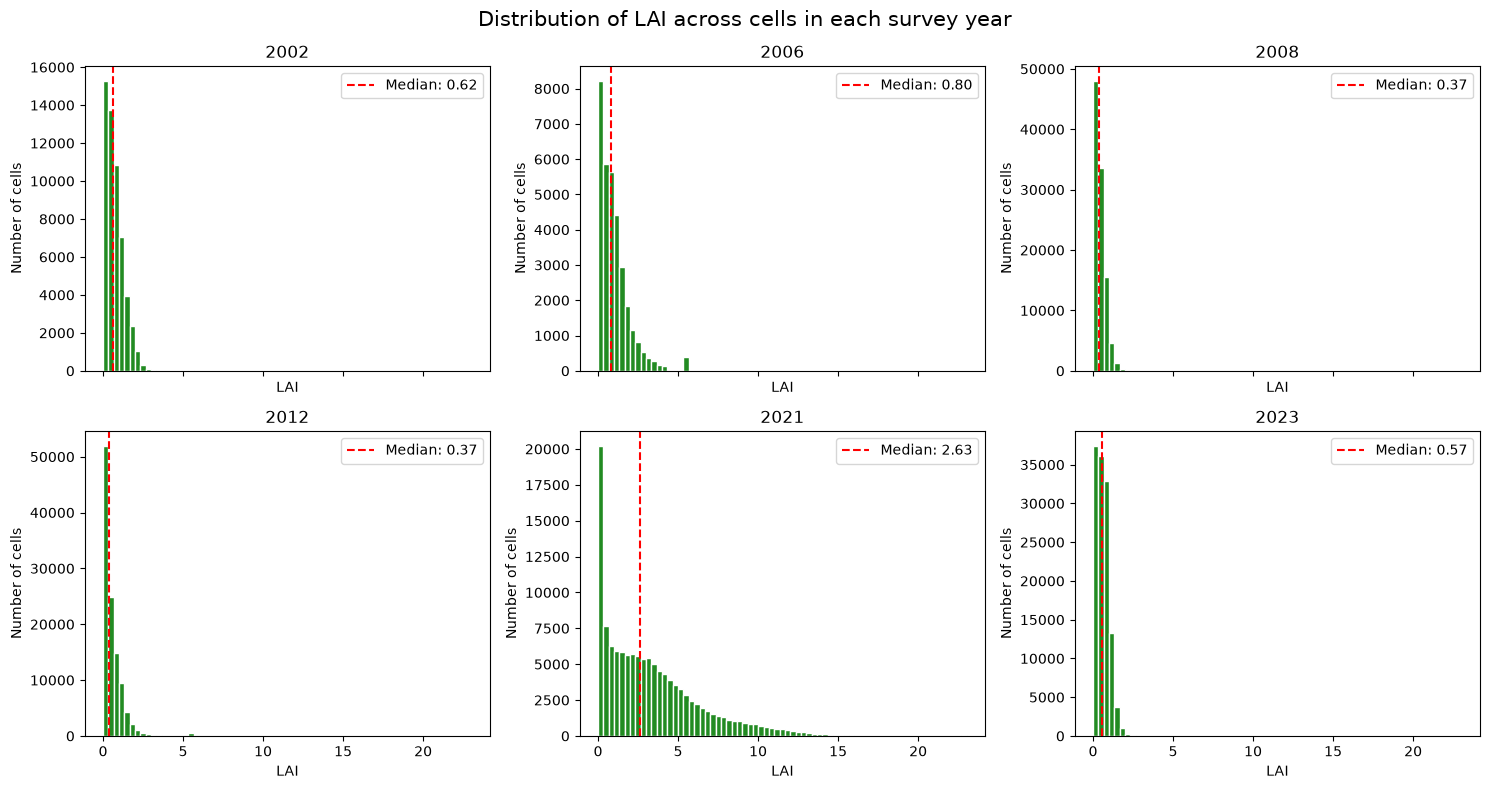

In [28]:
# Plot the LAI distribution separately for each LiDAR year.
years = sorted(attribute_table["LiDAR_year"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True,
    sharey=False,
)

# Use the same bins so the six distributions can be compared fairly.
lai_bins = np.linspace(0, attribute_table["LAI"].max(), 70,)

for year, axis in zip(years, axes.flat):
    year_lai = attribute_table.loc[attribute_table["LiDAR_year"] == year, "LAI", ]

    axis.hist(year_lai, bins=lai_bins, color="forestgreen", edgecolor="white",)

    axis.set_title(str(year))
    axis.set_xlabel("LAI")
    axis.set_ylabel("Number of cells")
    axis.axvline(year_lai.median(), color="red", linestyle="--", label=f"Median: {year_lai.median():.2f}",)
    axis.legend()

fig.suptitle("Distribution of LAI across cells in each survey year", fontsize=15)
plt.tight_layout()
plt.show()


## 2.5 Category values and included forest areas

This counts how many different labels each category contains. It does not calculate averages for category codes. The year counts were already calculated in Section 1.4 and are reused here.

In [29]:
# Count unique values and missing rows in category columns.
category_columns = [
    "AOI", "block", "blk", "cpmt", "scpt",
    "display_id", "spis", "SPIS_RF", "code",
]

category_summary = pd.DataFrame({
    "unique_non_missing_values": attribute_table[category_columns].nunique(),
    "missing_rows": attribute_table[category_columns].isna().sum(),
})

category_summary

,unique_non_missing_values,missing_rows
AOI,1,0
block,2,0
blk,5,0
cpmt,237,0
scpt,26,0
display_id,2221,0
spis,40,118182
SPIS_RF,10,115542
code,10,115542


## Section 2 findings

Record what the new column summaries, year tables, and category counts show. Do not copy counts from the archived notebook.

# 3. Exploring values and distributions

Section 1 already counted known unusual values. This section evaluates the **entire unfiltered table**, including every species, age, and available survey record. However, results are not pooled across years: every distribution, category chart, box plot, outlier rule, and validity check is calculated separately for each LiDAR year.

Each investigation therefore produces six panels or six sets of results. This is more thorough and prevents a large survey year or a year-specific processing method from hiding differences. Important additional checks are survey-to-survey scale changes, category imbalance, capped or rounded values, spatial or temporal clustering of extremes, unequal cell areas, and whether the patterns remain in the final Sitka spruce cohort.

## 3.1 Histograms of the main numerical variables

Each variable gets one figure containing six year-specific histograms. The six panels use the same bins and axes so their shapes can be compared fairly. The visible range is based on the full-table 0.1st–99.9th percentiles; this changes only the plot, not the data. Percentages are used because the years contain different numbers of rows. `Age` is left out until the cohort and age rules are agreed.

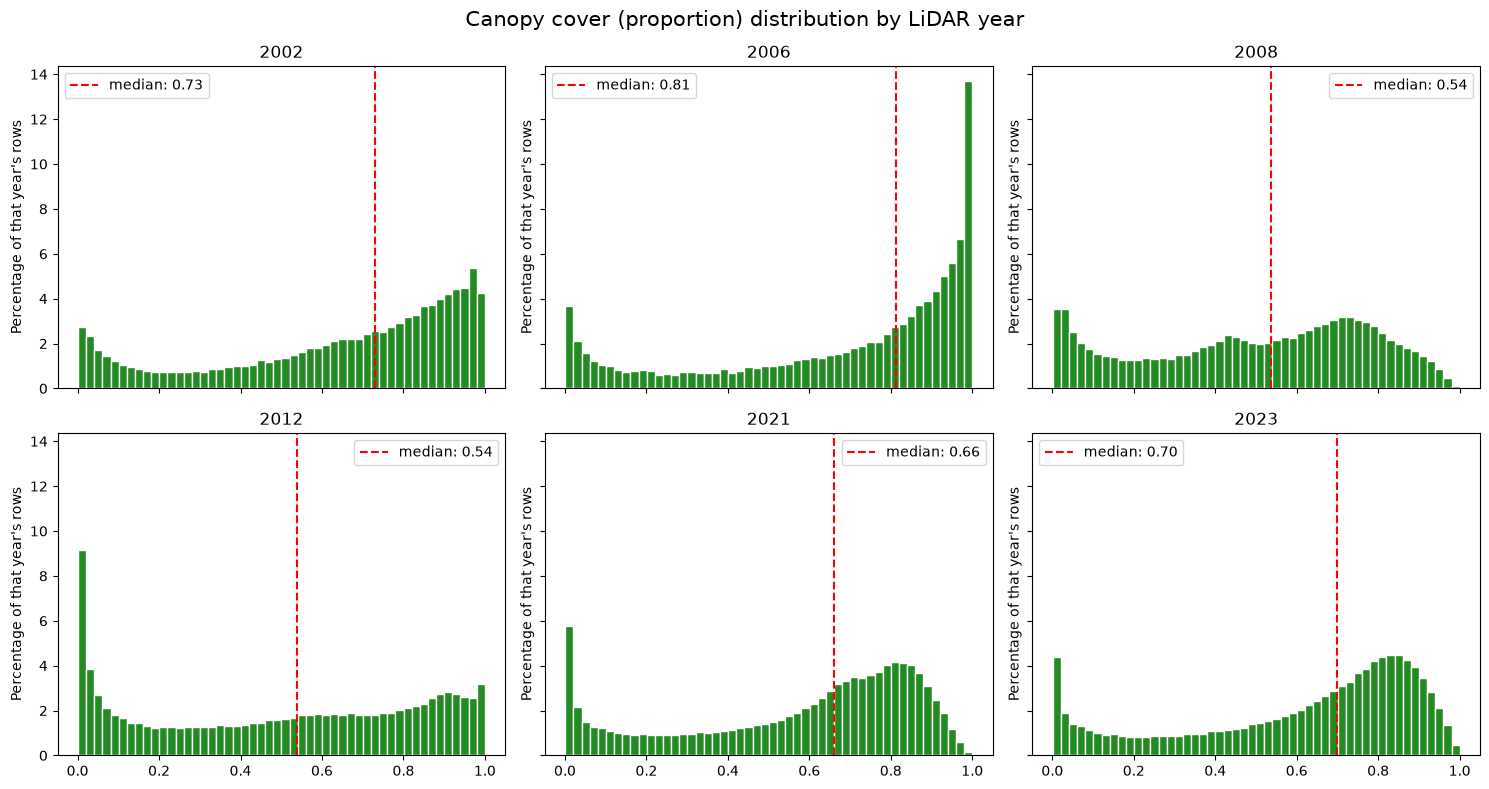

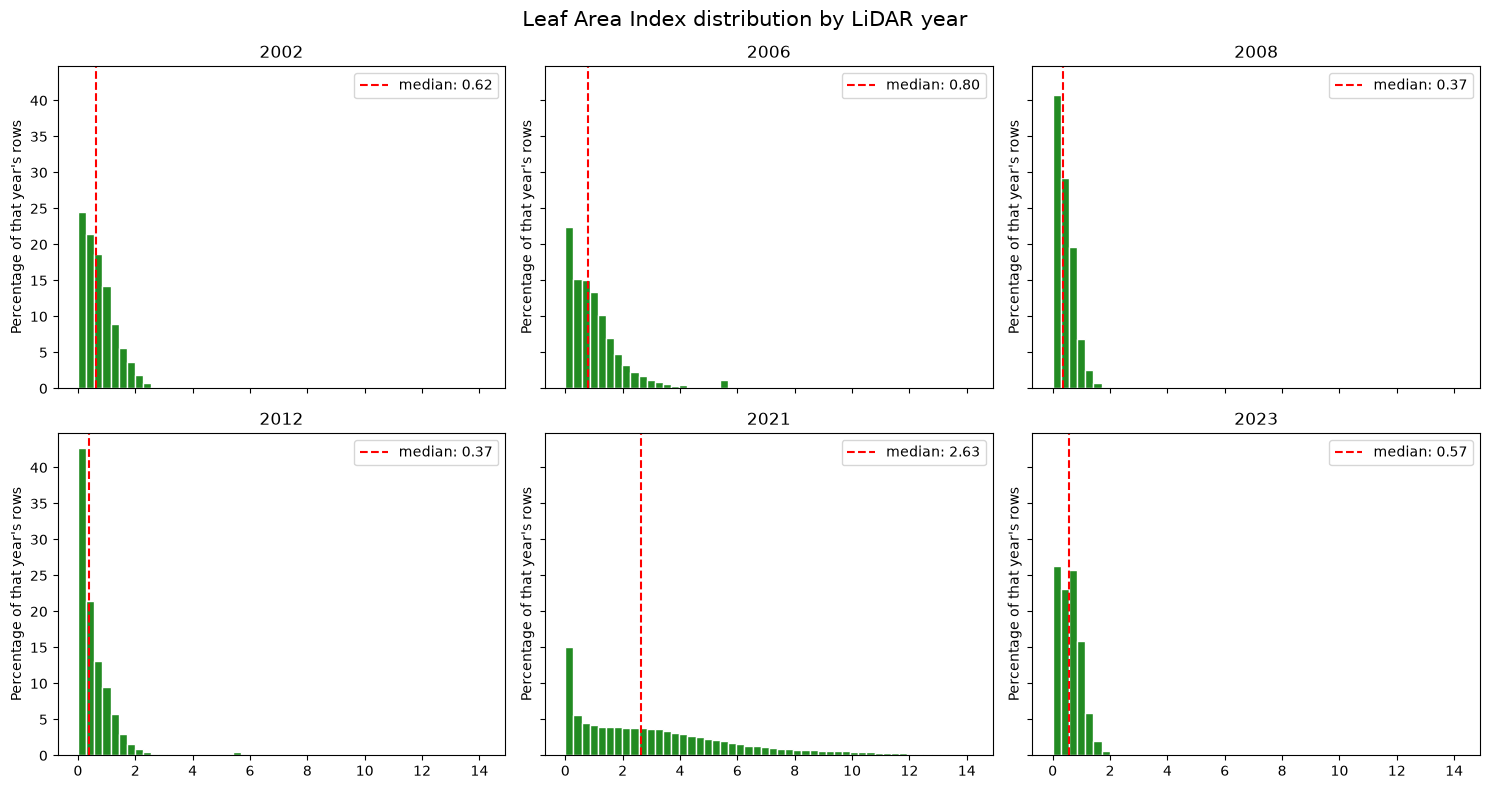

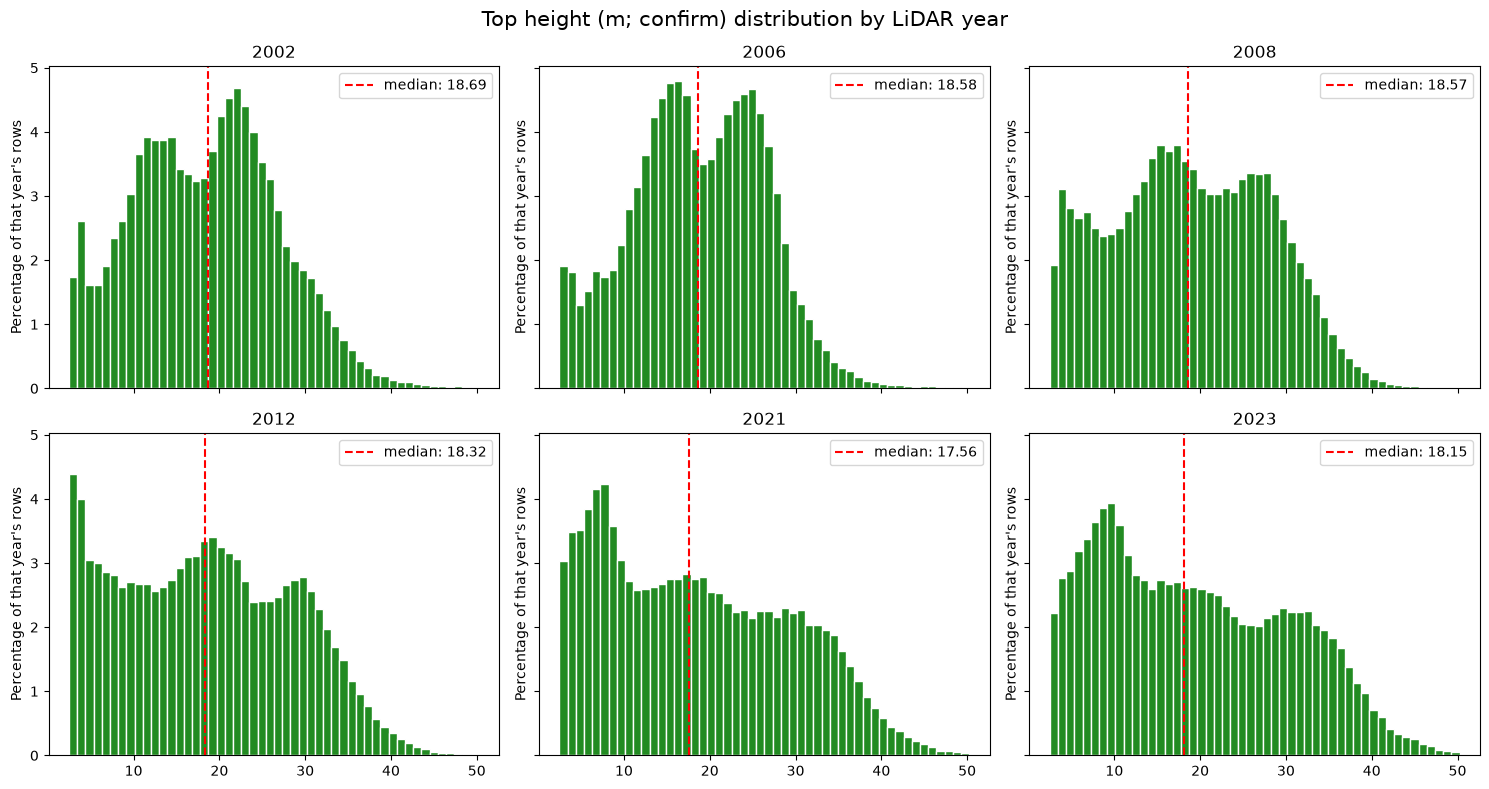

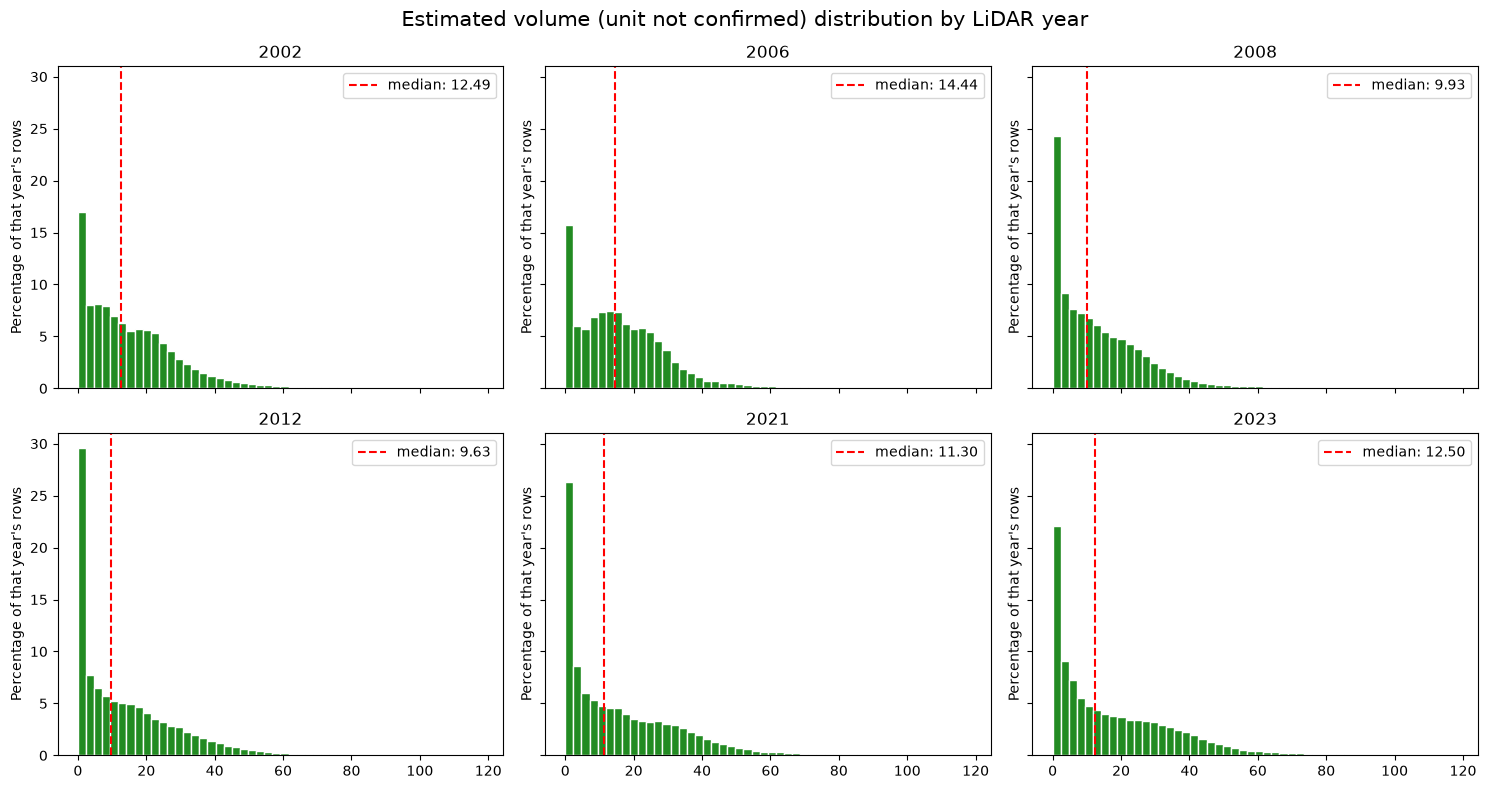

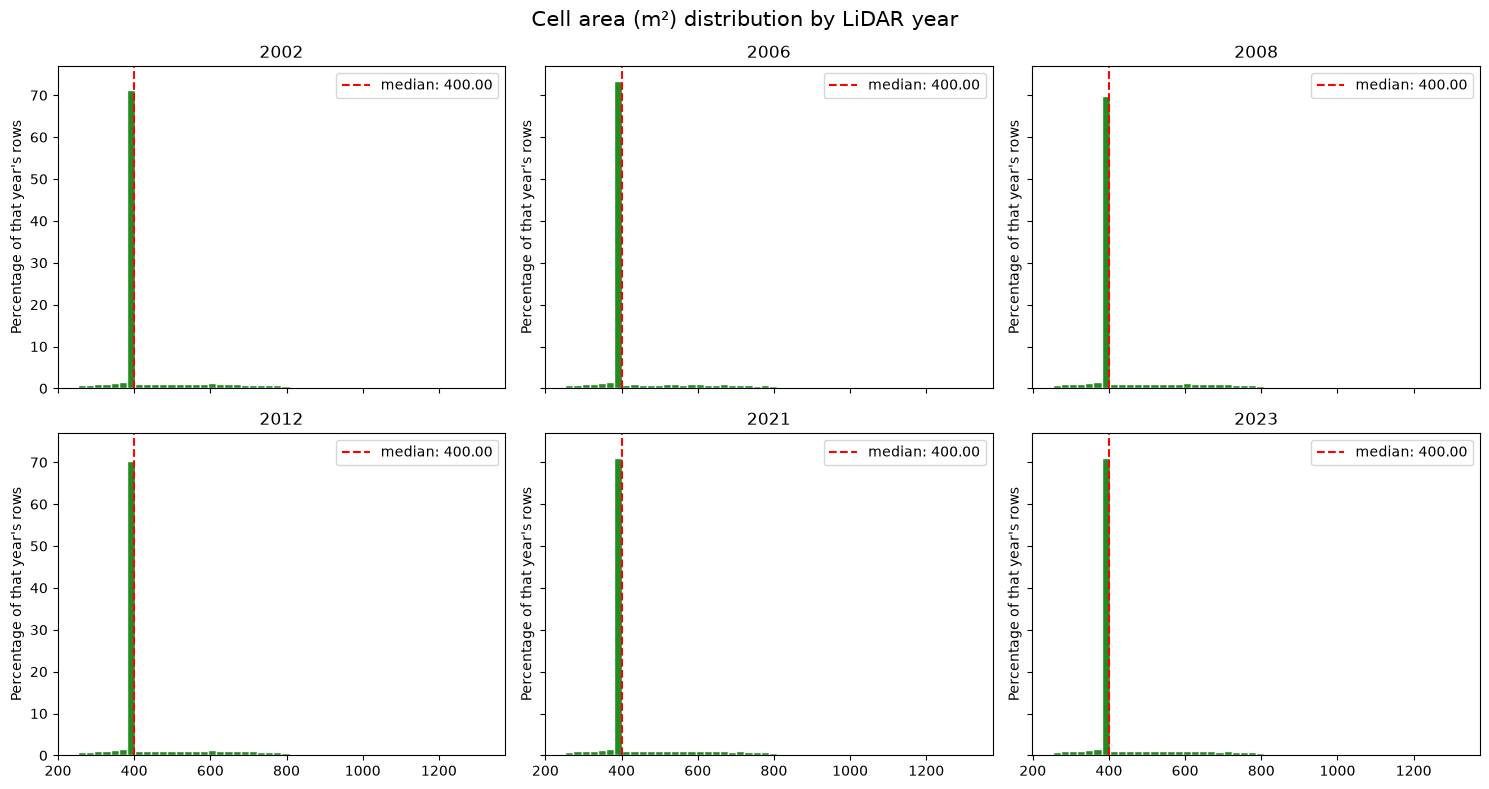

In [30]:
# Plot each numerical variable separately for all six survey years.
# Age is left out because many rows do not have a usable planting year.
histogram_variables = {
    "CanopyCover": "Canopy cover (proportion)",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height (m; confirm)",
    "Vol": "Estimated volume (unit not confirmed)",
    "area": "Cell area (m²)",
}

for variable, label in histogram_variables.items():
    all_values = attribute_table[variable].dropna()
    lower, upper = all_values.quantile([0.001, 0.999])
    common_bins = np.linspace(lower, upper, 51)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        values = year_data[variable].dropna()
        visible = values.loc[values.between(lower, upper)]
        weights = np.ones(len(visible)) * 100 / len(values)
        axis.hist(visible, bins=common_bins, weights=weights,
                  color="forestgreen", edgecolor="white")
        axis.axvline(values.median(), color="red", linestyle="--",
                     label=f"median: {values.median():.2f}")
        axis.set_title(str(year))
        axis.set_ylabel("Percentage of that year's rows")
        axis.legend()

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

## 3.2 Bar charts for important categories

Each category receives six year-specific panels. Within each year, every `identification` is counted once. Species, yield class, and block are static 2025 attributes, so differences between years describe which plots were covered by each survey; they do not show attributes changing through time. Percentages are used because survey sizes differ.

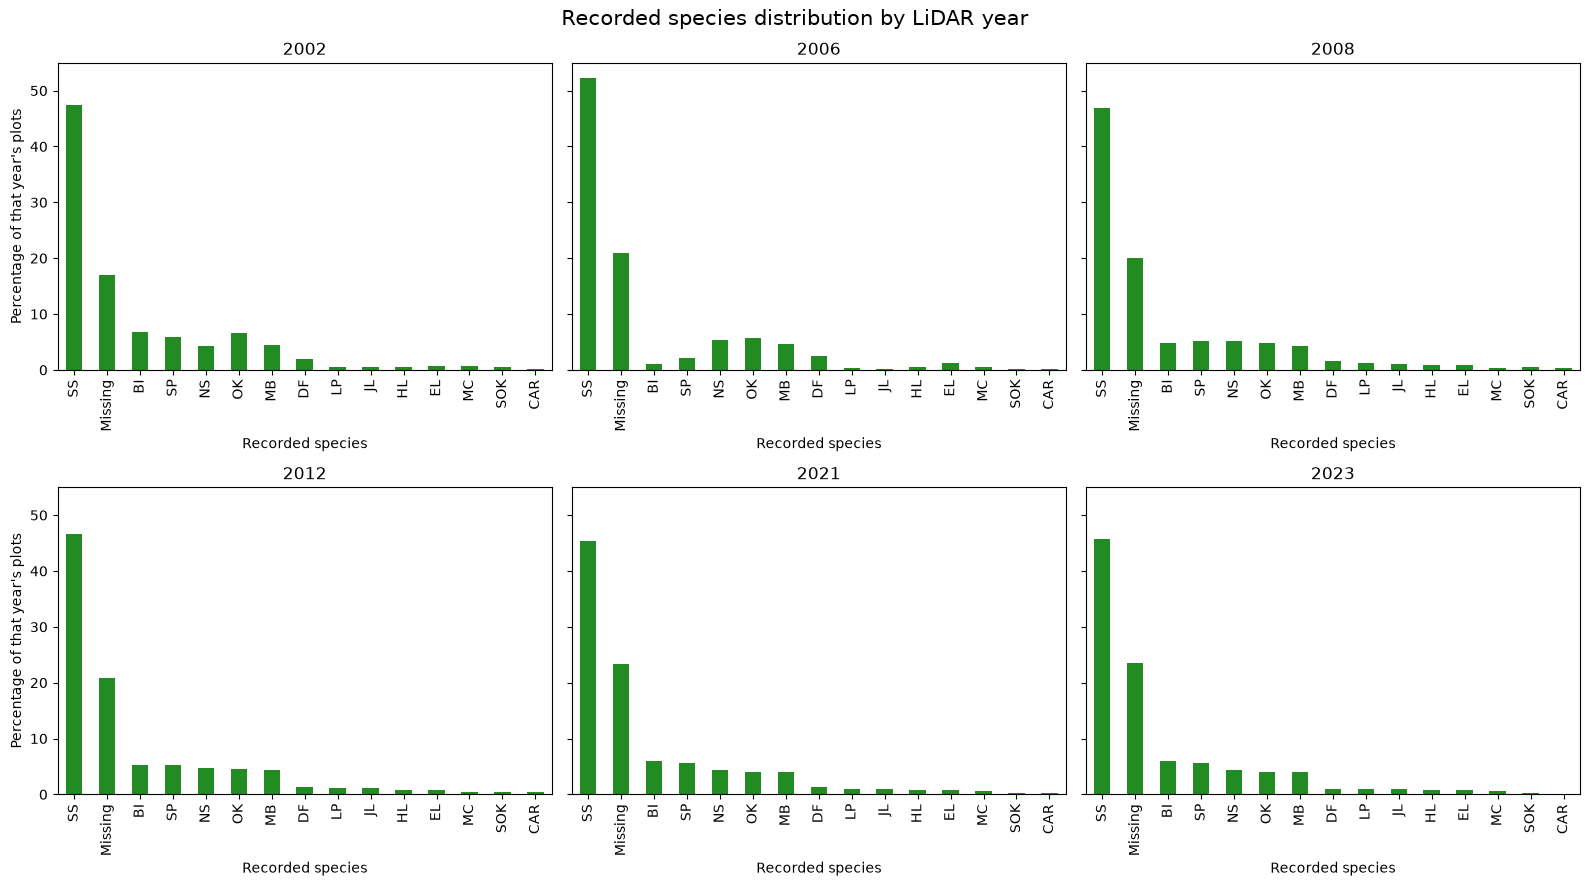

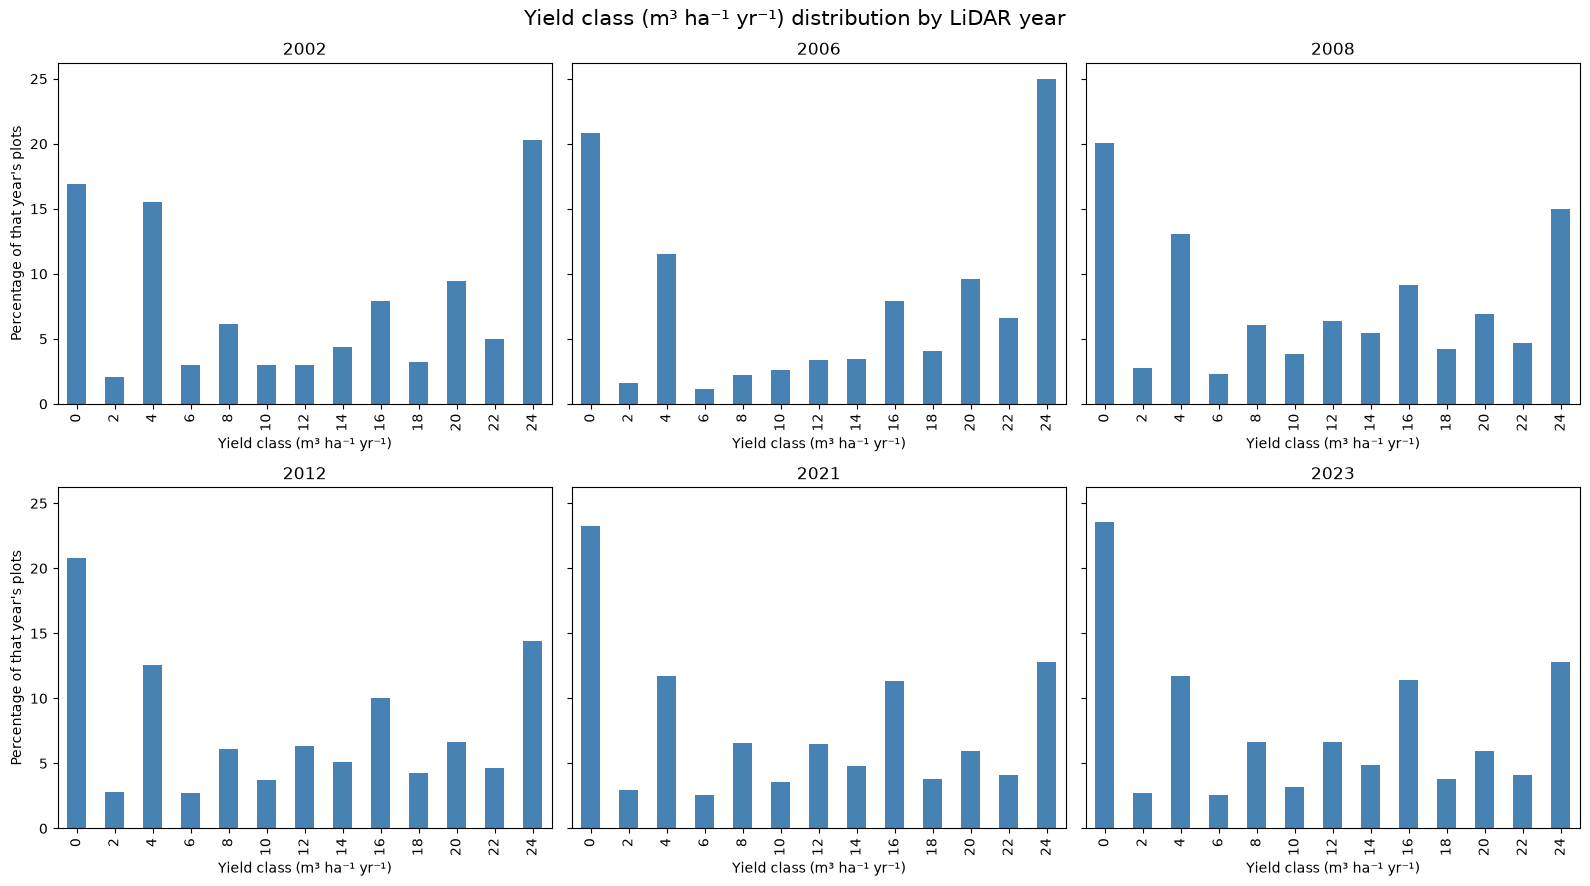

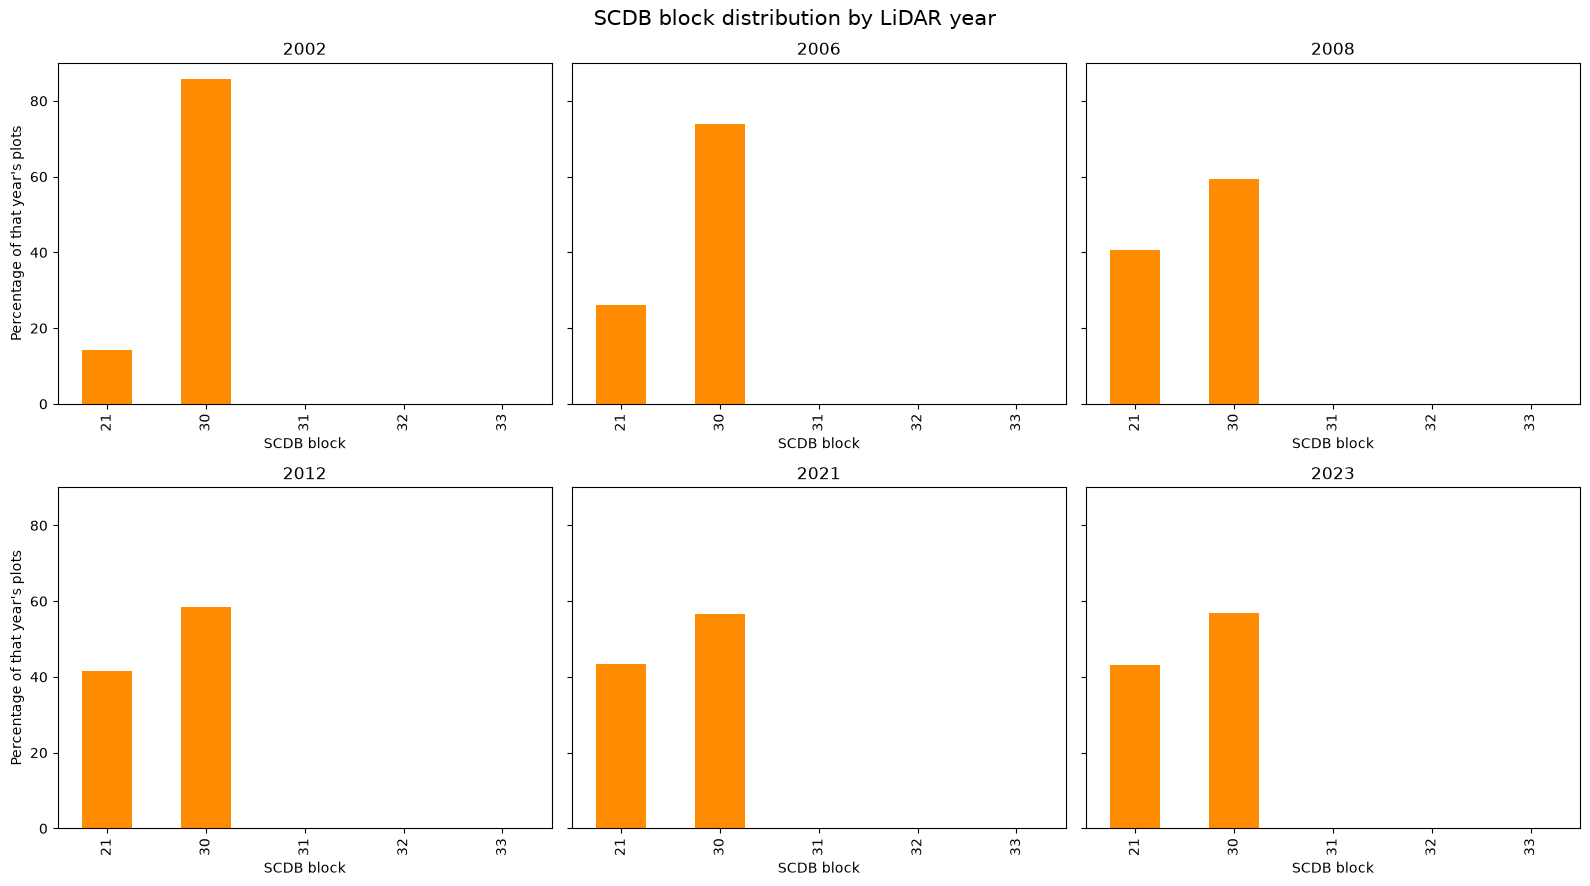

In [31]:
# Use the same category levels in all six panels.
one_row_per_plot = attribute_table.drop_duplicates("identification")
species_levels = (
    one_row_per_plot["spis"].fillna("Missing").value_counts().head(15).index
)
yield_class_levels = sorted(attribute_table["yldc"].unique())
block_levels = sorted(attribute_table["blk"].unique())

category_plots = {
    "spis": (species_levels, "Recorded species", "forestgreen"),
    "yldc": (yield_class_levels, "Yield class (m³ ha⁻¹ yr⁻¹)", "steelblue"),
    "blk": (block_levels, "SCDB block", "darkorange"),
}

for column, (levels, label, colour) in category_plots.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        plots_in_year = year_data.drop_duplicates("identification")
        values = plots_in_year[column]
        if column == "spis":
            values = values.fillna("Missing")
        percentages = (
            values.value_counts().reindex(levels, fill_value=0)
            / len(plots_in_year) * 100
        )
        percentages.plot.bar(ax=axis, color=colour)
        axis.set_title(str(year))
        axis.set_xlabel(label)
        axis.set_ylabel("Percentage of that year's plots")
        axis.tick_params(axis="x", labelrotation=90)

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

## 3.3 Box plots and statistical outliers by survey year

Each measurement receives six year-specific box plots with a shared vertical scale. Individual outlier points are hidden to keep the boxes readable. The table then calculates separate 1.5 × IQR limits for every variable and year. Statistical outliers may be genuine forest conditions and are not automatically removed.

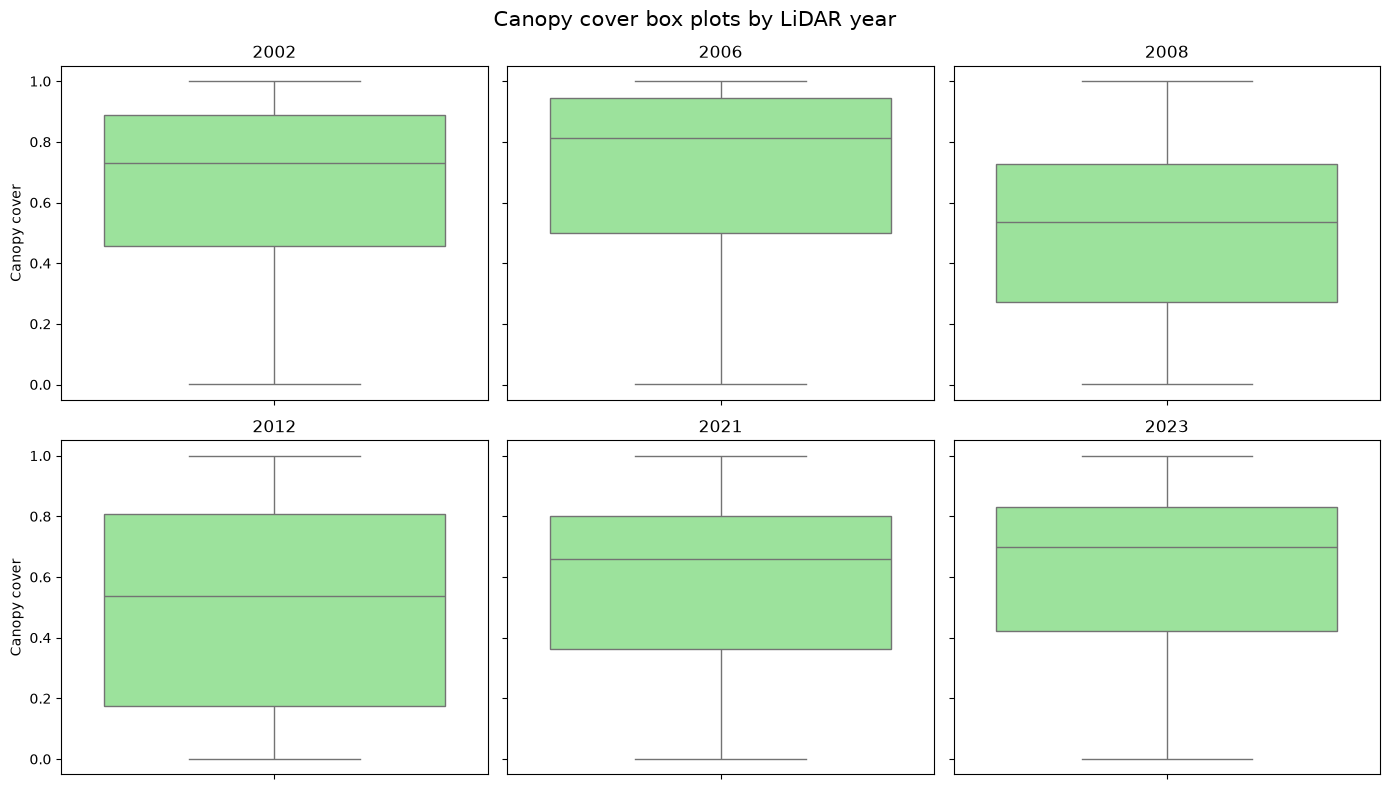

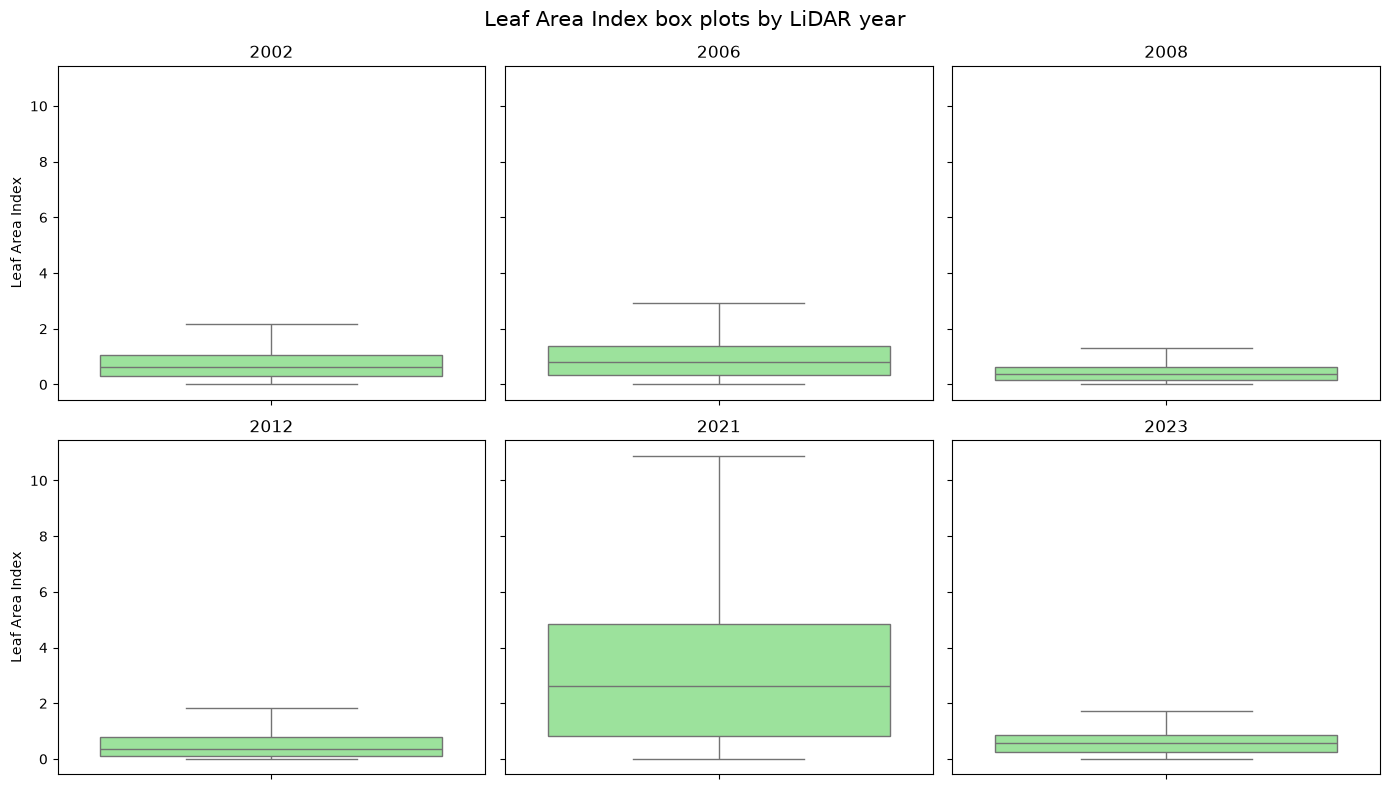

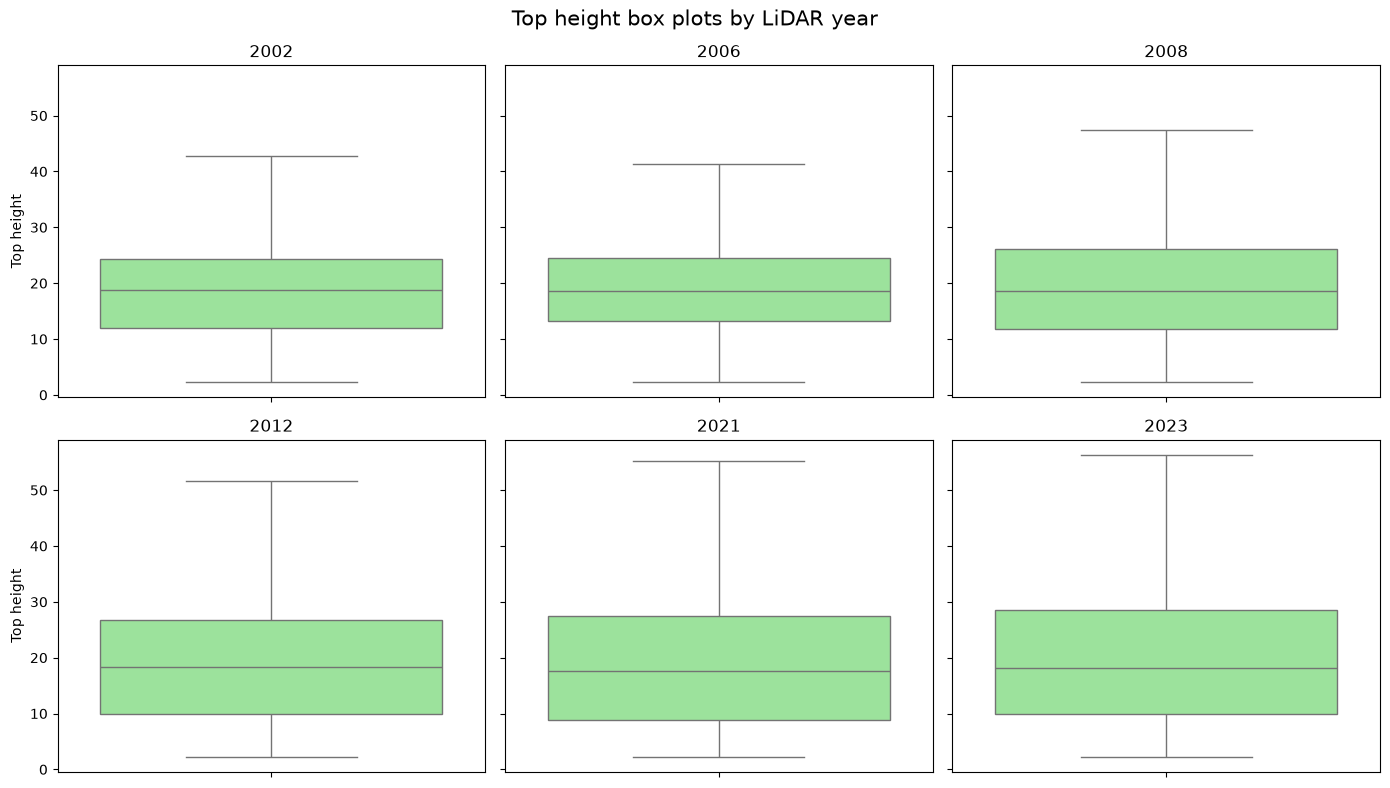

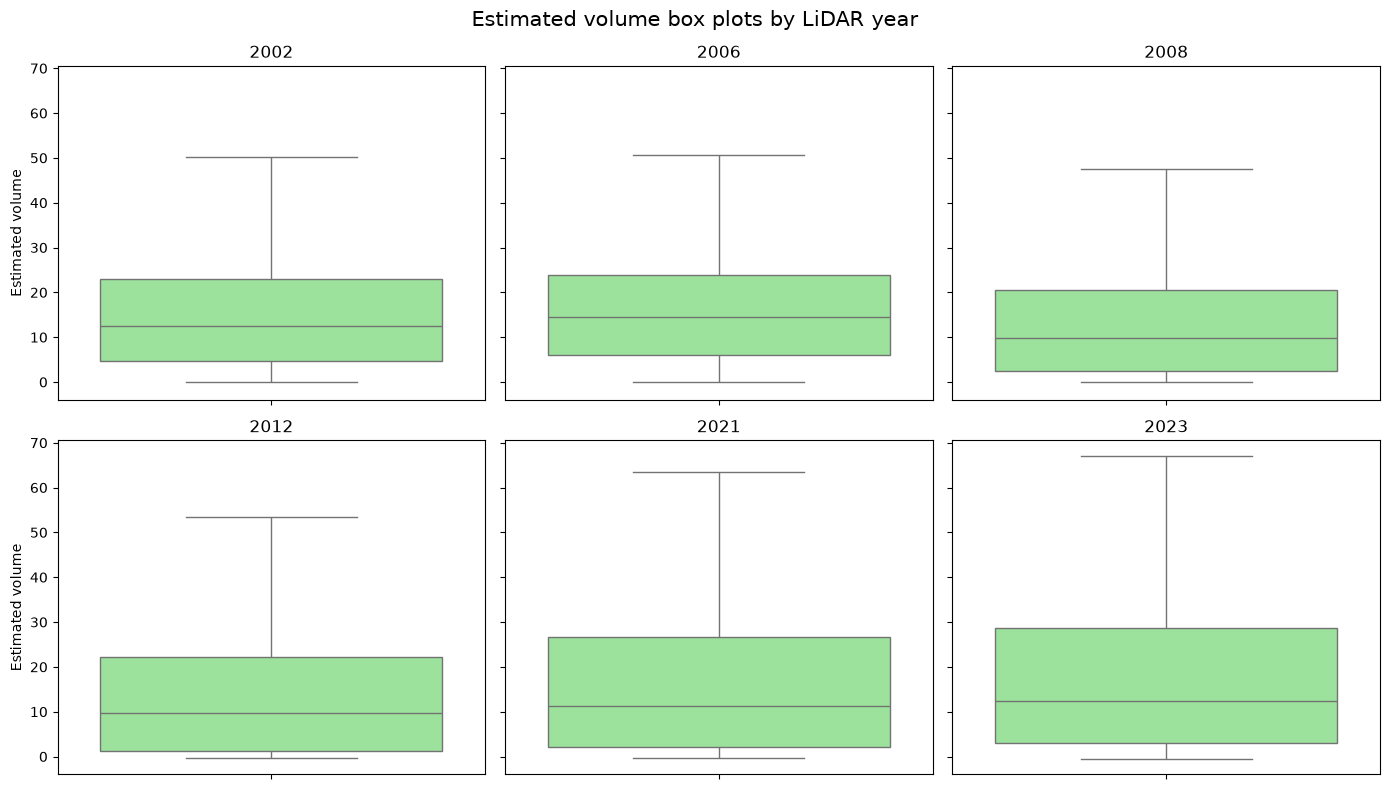

,LiDAR_year,variable,lower_limit,upper_limit,rows_outside,percentage_outside
0,2002,CanopyCover,-0.191044,1.535865,0,0.00
1,2002,LAI,-0.842243,2.180597,878,1.60
2,2002,Top_Height,-6.426652,42.711017,244,0.44
3,2002,Vol,-22.715716,50.239882,1449,2.64
4,2006,CanopyCover,-0.165910,1.609303,0,0.00
5,2006,LAI,-1.233027,2.937545,1406,4.29
6,2006,Top_Height,-3.601061,41.335616,106,0.32
7,2006,Vol,-20.630970,50.644881,731,2.23
8,2008,CanopyCover,-0.407887,1.408106,0,0.00
9,2008,LAI,-0.549655,1.322451,1644,1.59


In [32]:
# Compare four main measurements between survey years.
boxplot_variables = {
    "CanopyCover": "Canopy cover",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height",
    "Vol": "Estimated volume",
}

for variable, label in boxplot_variables.items():
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        sns.boxplot(data=year_data, y=variable, showfliers=False,
                    color="lightgreen", ax=axis)
        axis.set_title(str(year))
        axis.set_xlabel("")
        axis.set_ylabel(label)
    fig.suptitle(f"{label} box plots by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

# Count values outside the box-plot limits.
iqr_results = []
for year, year_data in data_by_year.items():
    for variable in boxplot_variables:
        q1, q3 = year_data[variable].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outside = ~year_data[variable].between(lower, upper)
        iqr_results.append({
            "LiDAR_year": year, "variable": variable,
            "lower_limit": lower, "upper_limit": upper,
            "rows_outside": outside.sum(),
            "percentage_outside": round(outside.mean() * 100, 2),
        })

iqr_outlier_summary = pd.DataFrame(iqr_results)
iqr_outlier_summary

## 3.4 Impossible, extreme, and capped values

Physical bounds, future dates, extreme measurements, and LAI capping are counted separately for all six years. The exact extreme-height and volume records are also returned for mapping or raw-LiDAR checking.

In [33]:
# Count values that violate simple physical or coding rules in each year.
domain_checks_by_year = pd.DataFrame({
    year: {
        "CanopyCover outside 0 to 1": (~d["CanopyCover"].between(0, 1)).sum(),
        "GapFraction outside 0 to 1": (~d["GapFraction"].between(0, 1)).sum(),
        "negative LAI": d["LAI"].lt(0).sum(),
        "Top_Height at or below zero": d["Top_Height"].le(0).sum(),
        "area at or below zero": d["area"].le(0).sum(),
        "planting year after 2025": d["plyr"].gt(2025).sum(),
        "last thinning after 2025": d["last_thinn"].gt(2025).sum(),
        "Top_Height above 150 m": d["Top_Height"].gt(150).sum(),
        "Vol above 1000": d["Vol"].gt(1000).sum(),
    }
    for year, d in data_by_year.items()
}).T

# Check whether LAI piles up at 5.5 or extends beyond it.
lai_cap_summary = (
    attribute_table.assign(
        LAI_at_5_5=np.isclose(attribute_table["LAI"], 5.5),
        LAI_above_5_5=attribute_table["LAI"].gt(5.5),
    )
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        rows_at_5_5=("LAI_at_5_5", "sum"),
        rows_above_5_5=("LAI_above_5_5", "sum"),
        maximum_LAI=("LAI", "max"),
    )
)

extreme_measurement_rows = (
    attribute_table.loc[
        attribute_table["Top_Height"].gt(150) | attribute_table["Vol"].gt(1000),
        ["identification", "LiDAR_year", "display_id", "spis",
         "CanopyCover", "LAI", "Top_Height", "Vol"],
    ]
    .sort_values(["identification", "LiDAR_year"])
)

display(domain_checks_by_year)
display(lai_cap_summary)
extreme_measurement_rows

,CanopyCover outside 0 to 1,GapFraction outside 0 to 1,negative LAI,Top_Height at or below zero,area at or below zero,planting year after 2025,last thinning after 2025,Top_Height above 150 m,Vol above 1000
2002,0,0,0,0,0,53,477,1,1
2006,0,0,0,0,0,0,477,0,0
2008,0,0,0,0,0,53,477,0,0
2012,0,0,0,0,0,53,477,2,0
2021,0,0,0,0,0,53,477,2,1
2023,0,0,0,0,0,40,477,1,0


,rows,rows_at_5_5,rows_above_5_5,maximum_LAI
LiDAR_year,,,,
2002,54857,41,0,5.500000
2006,32745,404,0,5.500000
2008,103412,22,0,5.500000
2012,110425,574,0,5.500000
2021,124695,0,25050,23.024964
2023,124814,5,0,5.500000


,identification,LiDAR_year,display_id,spis,CanopyCover,LAI,Top_Height,Vol
264090,235346,2012,701 30 2194 E,LP,0.552632,0.384268,307.176276,810.696472
383710,235346,2021,701 30 2194 E,LP,0.796140,3.407355,340.670316,1370.250722
508125,235346,2023,701 30 2194 E,LP,0.821182,0.822347,152.876694,409.845988
41096,366560,2002,701 30 2176 S,SS,0.643592,0.492858,248.795986,1152.403564
295110,366560,2012,701 30 2176 S,SS,0.404312,0.247479,216.838541,585.436377
417877,366560,2021,701 30 2176 S,SS,0.304674,0.613842,244.975687,532.659429


## Section 3 findings

Record the main year-specific distribution patterns and unusual records here. Statistical outliers are not automatically errors.